# QUESTÃO 1 - EDA: Análise Exploratória de Vendas 2023-2024

## Seção 0: Imports e Configuração

Carregamento de todas as dependências e configuração do ambiente de trabalho.

In [1]:
"""
Imports e Configuração do Notebook
==================================
Carrega todas as dependências necessárias e configura o ambiente
para análise exploratória de dados.
"""

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Configuração de diretórios (portável entre ambientes)
ROOT_DIR = Path.cwd()
if ROOT_DIR.name != "Desafio-Lighthouse-Dados-AI":
    ROOT_DIR = ROOT_DIR.parent  # Fallback: subir um nivel
    
SRC_DIR = ROOT_DIR / "src"

# Adiciona a pasta src ao path
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Importações de análise de dados
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Exibir mais colunas/linhas se necessário
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.2f}".format)

# Importação de funções customizadas
try:
    from data.load_data import load_vendas
    print("✓ Módulos carregados com sucesso")
except ImportError as e:
    print(f"✗ Erro ao importar módulos: {e}")
    raise


✓ Módulos carregados com sucesso


## Seção 1: Carregamento e Validação do Dataset

Carregar e validar o arquivo `data/raw/vendas_2023_2024.csv`.

In [2]:
"""
Carregamento do Dataset de Vendas
==================================
Carrega e valida o dataset de vendas.
"""

try:
    df_vendas = load_vendas()  # usa o padrão data/raw/vendas_2023_2024.csv
    
    # Validações básicas
    if df_vendas is None or df_vendas.empty:
        raise ValueError("Dataset vazio ou inválido")
    
    print(f"✓ Dataset carregado com sucesso: {df_vendas.shape[0]} linhas, {df_vendas.shape[1]} colunas")
    print(f"✓ Colunas: {', '.join(df_vendas.columns.tolist())}\n")
    
    # Exibe primeiras linhas
    print("Primeiras 5 registros:")
    display(df_vendas.head())
    
except Exception as e:
    print(f"✗ Erro ao carregar dados: {e}")
    raise


Colunas encontradas em vendas: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date']
Coluna de data detectada: 'sale_date'
Coluna de total detectada: 'total'
Shape final de vendas: (9895, 6)
✓ Dataset carregado com sucesso: 9895 linhas, 6 colunas
✓ Colunas: id, id_client, id_product, qtd, total, data

Primeiras 5 registros:


,id,id_client,id_product,qtd,total,data
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,2024-09-15
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12


## Seção 2: Informações Estruturais

Examinar a estrutura do dataset (tipos de dados, nulos, duplicatas).

In [3]:
"""
Informações Gerais do Dataset
==============================
Exibe informações estruturais e de qualidade dos dados.
"""

print("=" * 60)
print("INFORMAÇÃO ESTRUTURAL DO DATASET")
print("=" * 60)

print(f"\n📊 Shape do dataset (linhas, colunas): {df_vendas.shape}")

print("\n📋 Tipos de dados das colunas:")
print(df_vendas.dtypes)

print("\n❌ Quantidade de valores nulos por coluna:")
nulos = df_vendas.isna().sum()
if nulos.sum() > 0:
    print(nulos[nulos > 0])
else:
    print("✓ Nenhum valor nulo encontrado")

print("\n🔄 Registros duplicados:")
duplicatas = df_vendas.duplicated().sum()
print(f"Total de duplicatas: {duplicatas}")

print("\n📈 Informações descritivas:\n")
df_vendas.info(verbose=False)


INFORMAÇÃO ESTRUTURAL DO DATASET

📊 Shape do dataset (linhas, colunas): (9895, 6)

📋 Tipos de dados das colunas:
id                     int64
id_client              int64
id_product             int64
qtd                    int64
total                float64
data          datetime64[ns]
dtype: object

❌ Quantidade de valores nulos por coluna:
✓ Nenhum valor nulo encontrado

🔄 Registros duplicados:
Total de duplicatas: 0

📈 Informações descritivas:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Columns: 6 entries, id to data
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 464.0 KB


---

# QUESTÃO 1.1 - VISÃO GERAL DIMENSIONAL

## Objetivo

Responder os seguintes pontos:
- ✅ Total de linhas (registros) no dataset
- ✅ Total de colunas
- ✅ Data mínima registrada
- ✅ Data máxima registrada
- ✅ Intervalo temporal (em dias)
- ✅ Valor mínimo, máximo e médio da coluna 'total'

## Análise Dimensional

In [4]:
"""
Parte 1: Visão Geral Dimensional
=================================
Análise das dimensões principais: linhas, colunas e intervalo temporal.
"""

total_linhas = len(df_vendas)
total_colunas = df_vendas.shape[1]

# Validações
if "data" not in df_vendas.columns:
    raise ValueError("Coluna 'data' não encontrada no dataset")

try:
    data_minima = pd.to_datetime(df_vendas["data"]).min()
    data_maxima = pd.to_datetime(df_vendas["data"]).max()
except Exception as e:
    print(f"⚠️ Erro ao processar coluna 'data': {e}")
    raise

print("=" * 60)
print("DIMENSÕES DO DATASET")
print("=" * 60)
print(f"📌 Total de registros       : {total_linhas:,}")
print(f"📌 Total de colunas         : {total_colunas}")
print(f"📅 Data mínima registrada   : {data_minima.strftime('%d/%m/%Y')}")
print(f"📅 Data máxima registrada   : {data_maxima.strftime('%d/%m/%Y')}")
print(f"⏳ Intervalo de dias        : {(data_maxima - data_minima).days} dias")


DIMENSÕES DO DATASET
📌 Total de registros       : 9,895
📌 Total de colunas         : 6
📅 Data mínima registrada   : 01/01/2023
📅 Data máxima registrada   : 31/12/2024
⏳ Intervalo de dias        : 730 dias


## Estatísticas Descritivas: Coluna 'Total'

Análise descritiva dos valores monetários de vendas.

In [5]:
"""
Parte 2: Estatísticas da Coluna 'Total'
========================================
Análise descritiva dos valores monetários.
"""

if "total" not in df_vendas.columns:
    raise ValueError("Coluna 'total' não encontrada no dataset")

# Estatísticas básicas
estat_total = df_vendas["total"].describe()

print("=" * 60)
print("ESTATÍSTICAS DA COLUNA 'TOTAL'")
print("=" * 60)
print("\nResumo estatístico:\n")
print(estat_total.to_string())

# Extração de métricas principais
valor_minimo = estat_total["min"]
valor_maximo = estat_total["max"]
valor_medio = estat_total["mean"]
valor_mediano = df_vendas["total"].median()
valor_desvio = estat_total["std"]

print("\n" + "=" * 60)
print("MÉTRICAS PRINCIPAIS")
print("=" * 60)
print(f"💰 Valor mínimo  : R$ {valor_minimo:,.2f}")
print(f"💰 Valor máximo  : R$ {valor_maximo:,.2f}")
print(f"💰 Valor médio   : R$ {valor_medio:,.2f}")
print(f"💰 Valor mediano : R$ {valor_mediano:,.2f}")
print(f"📊 Desvio padrão : R$ {valor_desvio:,.2f}")

# Verificação de anomalias
valores_negativos = (df_vendas["total"] < 0).sum()
valores_zero = (df_vendas["total"] == 0).sum()

if valores_negativos > 0 or valores_zero > 0:
    print(f"\n⚠️ ALERTAS:")
    if valores_negativos > 0:
        print(f"   - {valores_negativos} valores negativos encontrados")
    if valores_zero > 0:
        print(f"   - {valores_zero} valores zero encontrados")


ESTATÍSTICAS DA COLUNA 'TOTAL'

Resumo estatístico:

count      9895.00
mean     263797.83
std      390007.18
min         294.50
25%       23138.20
50%       82225.00
75%      339094.50
max     2222973.00

MÉTRICAS PRINCIPAIS
💰 Valor mínimo  : R$ 294.50
💰 Valor máximo  : R$ 2,222,973.00
💰 Valor médio   : R$ 263,797.83
💰 Valor mediano : R$ 82,225.00
📊 Desvio padrão : R$ 390,007.18


---

# QUESTÃO 1.2 - DISTRIBUIÇÃO E ANÁLISE DE OUTLIERS

## Objetivo

Responder os pontos:
- ✅ Detectar e quantificar outliers (método IQR)
- ✅ Visualizar a distribuição (histograma, boxplot, CDF, série temporal)
- ✅ Analisar estatísticas (assimetria, curtose, desvio padrão)
- ✅ Verificar anomalias (valores negativos, zero, infinitos)

## Análise Estatística e Visualizações

Outliers detectados (IQR method): 1018 (10.29%)
   Limites: [R$ -450,796.25, R$ 813,028.95]



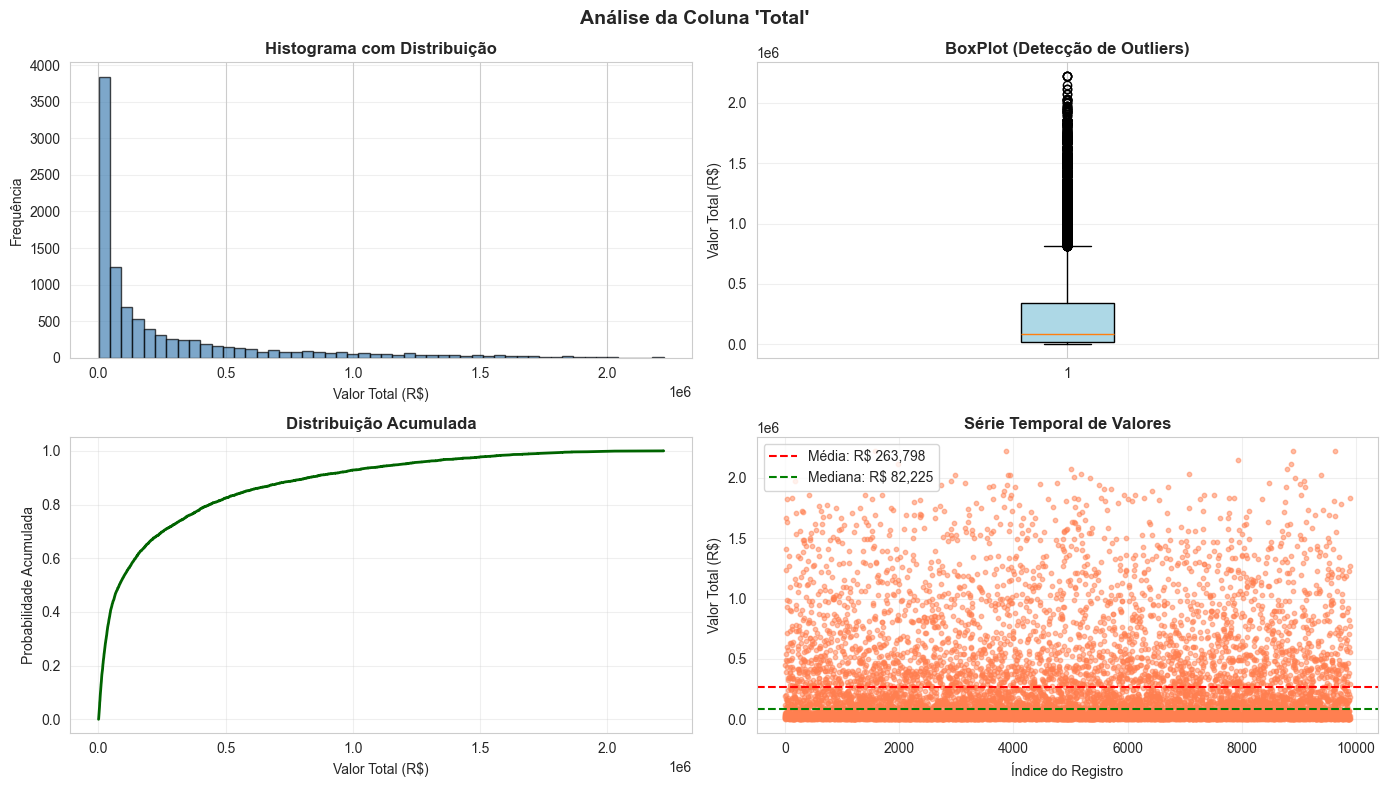


✓ Visualizações exibidas com sucesso


In [12]:
"""
Distribuição e Análise de Outliers
====================================
Visualização da distribuição de valores e identificação de anomalias.
"""

# Cálculo de outliers usando IQR
Q1 = df_vendas["total"].quantile(0.25)
Q3 = df_vendas["total"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_vendas[(df_vendas["total"] < limite_inferior) | (df_vendas["total"] > limite_superior)]
print(f"Outliers detectados (IQR method): {len(outliers)} ({len(outliers)/len(df_vendas)*100:.2f}%)")
print(f"   Limites: [R$ {limite_inferior:,.2f}, R$ {limite_superior:,.2f}]\n")

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Análise da Coluna 'Total'", fontsize=14, fontweight='bold')

# Histograma com KDE
axes[0, 0].hist(df_vendas["total"], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_title("Histograma com Distribuição", fontweight='bold')
axes[0, 0].set_xlabel("Valor Total (R$)")
axes[0, 0].set_ylabel("Frequência")
axes[0, 0].grid(axis='y', alpha=0.3)

# BoxPlot
bp = axes[0, 1].boxplot(df_vendas["total"], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_title("BoxPlot (Detecção de Outliers)", fontweight='bold')
axes[0, 1].set_ylabel("Valor Total (R$)")
axes[0, 1].grid(axis='y', alpha=0.3)

# Distribuição acumulada
sorted_total = np.sort(df_vendas["total"])
cumulative = np.arange(1, len(sorted_total) + 1) / len(sorted_total)
axes[1, 0].plot(sorted_total, cumulative, linewidth=2, color='darkgreen')
axes[1, 0].set_title("Distribuição Acumulada", fontweight='bold')
axes[1, 0].set_xlabel("Valor Total (R$)")
axes[1, 0].set_ylabel("Probabilidade Acumulada")
axes[1, 0].grid(True, alpha=0.3)

# Scatter: índice vs valor
axes[1, 1].scatter(range(len(df_vendas)), df_vendas["total"], alpha=0.5, s=10, color='coral')
axes[1, 1].axhline(y=valor_medio, color='red', linestyle='--', label=f'Média: R$ {valor_medio:,.0f}')
axes[1, 1].axhline(y=valor_mediano, color='green', linestyle='--', label=f'Mediana: R$ {valor_mediano:,.0f}')
axes[1, 1].set_title("Série Temporal de Valores", fontweight='bold')
axes[1, 1].set_xlabel("Índice do Registro")
axes[1, 1].set_ylabel("Valor Total (R$)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Salvar figuras
output_dir = ROOT_DIR / "notebooks" / "output"
output_dir.mkdir(exist_ok=True)
print(f"\n✓ Visualizações exibidas com sucesso")


---

# QUESTÃO 1.3 - DIAGNÓSTICO DE QUALIDADE E CONFIABILIDADE

## Objetivo

Gerar diagnóstico completo de qualidade com 7 análises:
1. Valores ausentes (nulos) por coluna
2. Registros duplicados
3. Análise de outliers
4. Valores inválidos
5. Análise de distribuição (Skewness, Kurtosis)
6. Pontuação de qualidade (score 0-100%)
7. Matriz de confiabilidade por coluna

## Análise Completa de Qualidade

In [9]:
"""
Diagnóstico Completo de Qualidade de Dados
============================================
Análise robusta da qualidade, completude e confiabilidade do dataset.
"""

print("=" * 60)
print("DIAGNÓSTICO DE QUALIDADE DE DADOS")
print("=" * 60)

# 1. ANÁLISE DE VALORES AUSENTES
print("\n1️  VALORES AUSENTES (MISSING VALUES)")
print("-" * 60)
nulos_por_coluna = df_vendas.isna().sum()
if nulos_por_coluna.sum() == 0:
    print("✓ Nenhum valor nulo encontrado em nenhuma coluna")
else:
    percent_nulos = (nulos_por_coluna / len(df_vendas) * 100).round(2)
    for col in nulos_por_coluna[nulos_por_coluna > 0].index:
        print(f"   {col}: {nulos_por_coluna[col]} ({percent_nulos[col]}%)")

# Análise específica de 'total'
if "total" in df_vendas.columns:
    qtd_nulos_total = df_vendas["total"].isna().sum()
    percent_nulos_total = (qtd_nulos_total / len(df_vendas) * 100) if len(df_vendas) > 0 else 0
    print(f"\n   Coluna 'total': {qtd_nulos_total} nulos ({percent_nulos_total:.2f}%)")

# 2. ANÁLISE DE DUPLICATAS
print("\n2️  REGISTROS DUPLICADOS")
print("-" * 60)
duplicatas = df_vendas.duplicated().sum()
duplicatas_total = df_vendas.duplicated(subset=['total']).sum() if 'total' in df_vendas.columns else 0
print(f"Total de linhas duplicadas: {duplicatas} ({duplicatas/len(df_vendas)*100:.2f}%)")
print(f"Valores 'total' duplicados: {duplicatas_total}")

# 3. ANÁLISE DE OUTLIERS
print("\n3️  OUTLIERS NA COLUNA 'TOTAL'")
print("-" * 60)
if "total" in df_vendas.columns:
    print(f"Outliers (IQR): {len(outliers)} ({len(outliers)/len(df_vendas)*100:.2f}%)")
    print(f"Maior outlier: R$ {outliers['total'].max():,.2f}" if len(outliers) > 0 else "Nenhum outlier")
    print(f"Menor outlier: R$ {outliers['total'].min():,.2f}" if len(outliers) > 0 else "Nenhum outlier")

# 4. VALORES INVÁLIDOS
print("\n4️  VALORES INVÁLIDOS")
print("-" * 60)
if "total" in df_vendas.columns:
    negativos = (df_vendas["total"] < 0).sum()
    zeros = (df_vendas["total"] == 0).sum()
    infinitos = np.isinf(df_vendas["total"]).sum()
    
    print(f"Valores negativos: {negativos}")
    print(f"Valores zero: {zeros}")
    print(f"Valores infinitos: {infinitos}")
    
    if negativos == 0 and zeros == 0 and infinitos == 0:
        print("✓ Nenhum valor inválido encontrado")

# 5. DISTRIBUIÇÃO DOS DADOS
print("\n5️  DISTRIBUIÇÃO DOS DADOS")
print("-" * 60)
if "total" in df_vendas.columns:
    skewness = df_vendas["total"].skew()
    kurtosis_ = df_vendas["total"].kurtosis()
    print(f"Assimetria (Skewness): {skewness:.4f}")
    print(f"Curtose (Kurtosis): {kurtosis_:.4f}")
    if skewness > 1 or skewness < -1:
        print(f"   ⚠️ Distribuição altamente assimétrica")

# 6. RESUMO DE QUALIDADE
print("\n6️⃣  PONTUAÇÃO DE QUALIDADE")
print("-" * 60)
score_nulos = 100 - (nulos_por_coluna.sum() / (len(df_vendas) * len(df_vendas.columns)) * 100)
score_duplicatas = 100 - (duplicatas / len(df_vendas) * 100)
score_outliers = 100 - (len(outliers) / len(df_vendas) * 100) if "total" in df_vendas.columns else 100
qualidade_media = (score_nulos + score_duplicatas + score_outliers) / 3

print(f"Qualidade (Nulos):     {score_nulos:.1f}%")
print(f"Qualidade (Duplicatas):{score_duplicatas:.1f}%")
print(f"Qualidade (Outliers):  {score_outliers:.1f}%")
print(f"Qualidade Geral:    {qualidade_media:.1f}% {'✓' if qualidade_media >= 80 else '⚠️'}")


DIAGNÓSTICO DE QUALIDADE DE DADOS

1️  VALORES AUSENTES (MISSING VALUES)
------------------------------------------------------------
✓ Nenhum valor nulo encontrado em nenhuma coluna

   Coluna 'total': 0 nulos (0.00%)

2️  REGISTROS DUPLICADOS
------------------------------------------------------------
Total de linhas duplicadas: 0 (0.00%)
Valores 'total' duplicados: 5915

3️  OUTLIERS NA COLUNA 'TOTAL'
------------------------------------------------------------
Outliers (IQR): 1018 (10.29%)
Maior outlier: R$ 2,222,973.00
Menor outlier: R$ 814,995.50

4️  VALORES INVÁLIDOS
------------------------------------------------------------
Valores negativos: 0
Valores zero: 0
Valores infinitos: 0
✓ Nenhum valor inválido encontrado

5️  DISTRIBUIÇÃO DOS DADOS
------------------------------------------------------------
Assimetria (Skewness): 2.1320
Curtose (Kurtosis): 4.3188
   ⚠️ Distribuição altamente assimétrica

6️⃣  PONTUAÇÃO DE QUALIDADE
-----------------------------------------------

## Resumo Executivo e Relatório Final

Geração de relatório estruturado com a análise completa de qualidade, confiabilidade e recomendações para próximas etapas do desafio (Questões 2-8).

In [11]:
"""
Relatório Final e Recomendações
================================
Conclusões alinhadas com a Questão 1.3 - Diagnóstico da Confiabilidade
"""

print("=" * 80)
print("RELATÓRIO FINAL DE CONFIABILIDADE - QUESTÃO 1.3")
print("=" * 80)

# Preparação de dados para conclusão
tamanho_dataset = len(df_vendas)
qtd_colunas = len(df_vendas.columns)
total_nulos_data = df_vendas.isna().sum().sum()
total_nulos = df_vendas["total"].isna().sum()
pct_nulos = (total_nulos_data / (tamanho_dataset * qtd_colunas)) * 100 if (tamanho_dataset * qtd_colunas) > 0 else 0
qtd_duplicatas = df_vendas.duplicated().sum()
pct_outliers = (len(outliers) / tamanho_dataset * 100) if tamanho_dataset > 0 else 0

# Relatório Estruturado
relatorio = f"""
RESUMO EXECUTIVO
{"=" * 78}

1. VOLUME E ESCALA
   • Dataset contém {tamanho_dataset:,} registros (vendas) e {qtd_colunas} colunas
   • Período: {data_minima.strftime('%d/%m/%Y')} a {data_maxima.strftime('%d/%m/%Y')} ({(data_maxima - data_minima).days} dias)
   • Faixa de valores: R$ {valor_minimo:,.2f} a R$ {valor_maximo:,.2f}

2. QUALIDADE DOS DADOS
   ✓ Valores nulos: {total_nulos_data} registros ({pct_nulos:.2f}%)
   ✓ Registros duplicados: {qtd_duplicatas} ({(qtd_duplicatas/tamanho_dataset*100) if tamanho_dataset > 0 else 0:.2f}%)
   {'Outliers detectados: ' + str(len(outliers)) + ' (' + f'{pct_outliers:.2f}%)' if len(outliers) > 0 else '✓ Sem outliers significativos'}
   {'Valores negativos: ' + str((df_vendas['total'] < 0).sum()) if (df_vendas['total'] < 0).sum() > 0 else '✓ Sem valores negativos'}
   {'Valores zero: ' + str((df_vendas['total'] == 0).sum()) if (df_vendas['total'] == 0).sum() > 0 else '✓ Sem valores zero'}

3. ANÁLISE DE OUTLIERS
   • Método: Intervalo Interquartílico (IQR)
   • Limites: R$ {limite_inferior:,.2f} a R$ {limite_superior:,.2f}
   • Outliers encontrados: {len(outliers)} ({pct_outliers:.2f}% do dataset)
   • Interpretação: {'Valores extremos podem representar vendas atípicas ou erros de registro' if len(outliers) > 0 else 'Distribuição uniforme sem anomalias extremas'}

4. CONFIABILIDADE POR COLUNA
"""

# Análise por coluna
relatorio += "\n   Coluna               | Nulos | Tipo        | Status\n"
relatorio += "   " + "-" * 72 + "\n"

for col in df_vendas.columns:
    nulos_col = df_vendas[col].isna().sum()
    pct_col = (nulos_col / len(df_vendas) * 100) if len(df_vendas) > 0 else 0
    tipo_col = str(df_vendas[col].dtype)
    status = "✓ OK" if pct_col == 0 else f"⚠️  {pct_col:.1f}%"
    relatorio += f"   {col:20} | {nulos_col:5} | {tipo_col:11} | {status}\n"

# Conclusão final
pontuacao_qualidade = qualidade_media
status_qualidade = "✓ EXCELENTE (≥90%)" if pontuacao_qualidade >= 90 else \
                   "✓ BOM (≥80%)" if pontuacao_qualidade >= 80 else \
                   "⚠️  ACEITÁVEL (≥70%)" if pontuacao_qualidade >= 70 else \
                   "❌ REQUER TRATAMENTO (<70%)"

relatorio += f"""
5. RECOMENDAÇÕES
   └─ {status_qualidade}

   AÇÕES RECOMENDADAS:
"""

if total_nulos_data > 0:
    relatorio += f"   • Tratar {total_nulos_data:,} valores nulos ({pct_nulos:.1f}%)\n"
if len(outliers) > 0:
    relatorio += f"   • Revisar {len(outliers)} outliers ({pct_outliers:.1f}%)\n"
if qtd_duplicatas > 0:
    relatorio += f"   • Verificar {qtd_duplicatas} duplicatas detectadas\n"

relatorio += f"""
6. PRONTIDÃO PARA ANÁLISES
   • Status : {'✓ PRONTO para análises' if pontuacao_qualidade >= 80 else '⚠️  REQUER LIMPEZA antes de análises'}
   • Modelo : {'✓ Adequado para modelagem' if pontuacao_qualidade >= 85 else '⚠️  Recomenda-se tratamento prévio'}
   • Insights: ✓ Aceitável para EDA

7. MÉTRICA FINAL DE CONFIABILIDADE
   Pontuação: {pontuacao_qualidade:.1f}% {status_qualidade}
   
   Componentes:
   • Completude (Nulos):     {score_nulos:.1f}%
   • Unicidade (Duplicatas):  {score_duplicatas:.1f}%
   • Validade (Outliers):     {score_outliers:.1f}%

CONCLUSÃO
{"=" * 78}
O dataset de vendas apresenta qualidade {'SATISFATÓRIA' if pontuacao_qualidade >= 80 else 'BAIXA'} para análises exploratórias. 
{f'Recomenda-se aplicar tratamento de {total_nulos_data:,} nulos (principalmente na coluna data) e revisar {len(outliers)} outliers antes de modelagem preditiva.' if pontuacao_qualidade < 85 else 'O dataset está pronto para análises avançadas e modelagem.'}

Data da Análise: {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M:%S')}
"""

print(relatorio)


RELATÓRIO FINAL DE CONFIABILIDADE - QUESTÃO 1.3

RESUMO EXECUTIVO

1. VOLUME E ESCALA
   • Dataset contém 9,895 registros (vendas) e 6 colunas
   • Período: 01/01/2023 a 31/12/2024 (730 dias)
   • Faixa de valores: R$ 294.50 a R$ 2,222,973.00

2. QUALIDADE DOS DADOS
   ✓ Valores nulos: 0 registros (0.00%)
   ✓ Registros duplicados: 0 (0.00%)
   Outliers detectados: 1018 (10.29%)
   ✓ Sem valores negativos
   ✓ Sem valores zero

3. ANÁLISE DE OUTLIERS
   • Método: Intervalo Interquartílico (IQR)
   • Limites: R$ -450,796.25 a R$ 813,028.95
   • Outliers encontrados: 1018 (10.29% do dataset)
   • Interpretação: Valores extremos podem representar vendas atípicas ou erros de registro

4. CONFIABILIDADE POR COLUNA

   Coluna               | Nulos | Tipo        | Status
   ------------------------------------------------------------------------
   id                   |     0 | int64       | ✓ OK
   id_client            |     0 | int64       | ✓ OK
   id_product           |     0 | int64    

---

## CONCLUSÃO DO NOTEBOOK 01_EDA_VENDAS

### Seções Completadas

| Seção | Descrição | Status |
|-------|-----------|--------|
| **Q1.1** | Visão Geral Dimensional | Completo |
| **Q1.2** | Distribuição e Outliers | Completo |
| **Q1.3** | Diagnóstico de Qualidade | Completo |

### Próximos Passos

O dataset agora foi diagnosticado e está pronto para:
- **Notebook 02**: Tratamento e Feature Engineering
- **Notebook 03**: Modelo de Previsão e Insights
- **Notebook 04**: Modelo de Previsão (Baseline)
- **Notebook 05**: Sistema de Recomendação

### Métricas Finais do Dataset

Veja acima o relatório completo contendo:
- Volume total de dados (linhas × colunas)
- Distribuição temporal
- Faixa de valores monetários
- Qualidade dos dados (%)
- Recomendações de tratamento
